## Memory Pipeline — Results Analysis

Loads and analyzes turn-level evaluation results across all 12 configurations (3 embedding × 4 generation models). Each configuration is evaluated over multi-turn conversations, capturing how well the pipeline resolves references and maintains context across turns. Covers both query resolution quality and answer quality, and answer quality, and generates summary tables, heatmaps,and bar charts for embedding and generation model comparisons.

Found 12 turn-result file(s):
  reranking_bge_mistral_v01_turn_results.csv: 95 turns  [bge + mistral_v01]
  reranking_bge_mistral_v02_turn_results.csv: 95 turns  [bge + mistral_v02]
  reranking_bge_phi2_turn_results.csv: 95 turns  [bge + phi2]
  reranking_bge_qwen_turn_results.csv: 95 turns  [bge + qwen]
  reranking_minilm_mistral_v01_turn_results.csv: 95 turns  [minilm + mistral_v01]
  reranking_minilm_mistral_v02_turn_results.csv: 95 turns  [minilm + mistral_v02]
  reranking_minilm_phi2_turn_results.csv: 95 turns  [minilm + phi2]
  reranking_minilm_qwen_turn_results.csv: 95 turns  [minilm + qwen]
  reranking_multiqa_mistral_v01_turn_results.csv: 95 turns  [multiqa + mistral_v01]
  reranking_multiqa_mistral_v02_turn_results.csv: 95 turns  [multiqa + mistral_v02]
  reranking_multiqa_phi2_turn_results.csv: 95 turns  [multiqa + phi2]
  reranking_multiqa_qwen_turn_results.csv: 95 turns  [multiqa + qwen]

Loaded  : 1140 total turns
Configs : 12  ->  ['bge_mistral_v01', 'bge_mistral_v02', '

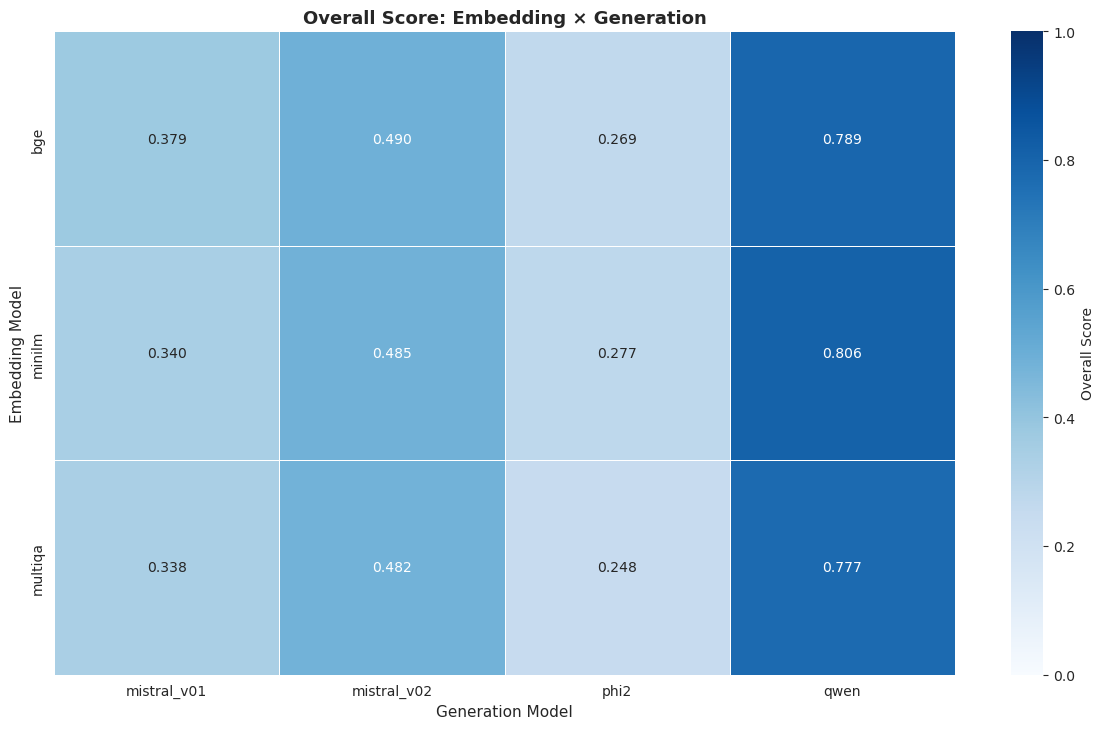




................................................................................
BEST CONFIGURATION PER METRIC
................................................................................
  res_Semantic Similarity            : bge_qwen                             (0.9539)  [higher is better]
  res_Token-F1                       : bge_qwen                             (0.9218)  [higher is better]
  res_Entity-F1                      : bge_qwen                             (0.9328)  [higher is better]
  res_Token Overlap                  : bge_qwen                             (0.8842)  [higher is better]
  ans_Entity-F1                      : minilm_qwen                          (0.7611)  [higher is better]
  ans_Token-F1                       : minilm_qwen                          (0.7383)  [higher is better]
  ans_Cosine Similarity              : minilm_qwen                          (0.9031)  [higher is better]
  ans_Semantic Similarity            : minilm_qwen                    

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# ============================================================================
# STYLE
# ============================================================================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# ============================================================================
# CONFIGURATION
# ============================================================================
EMBEDDINGS = {
    'minilm':  'all-MiniLM-L6-v2',
    'bge':     'BAAI/bge-base-en-v1.5',
    'multiqa': 'sentence-transformers/multi-qa-mpnet-base-dot-v1',
}

GENERATIONS = {
    'qwen':        'Qwen/Qwen2.5-7B-Instruct',
    'mistral_v01': 'mistralai/Mistral-7B-v0.1',
    'mistral_v02': 'mistralai/Mistral-7B-Instruct-v0.2',
    'phi2':        'microsoft/phi-2',
}

# ── Exact column names from evaluate_conversations() ──────────────────────
RES_METRICS = [
    'res_Semantic Similarity',
    'res_Token-F1',
    'res_Entity-F1',
    'res_Token Overlap',
]

ANS_METRICS = [
    'ans_Entity-F1',
    'ans_Token-F1',
    'ans_Cosine Similarity',
    'ans_Semantic Similarity',
    'ans_Answer Relevance',
    'ans_Hallucination',
    'ans_Faithfulness',
    'ans_Completeness',
    'ans_Key Info',
    'ans_Exact Match',
    'Latency (s)',
]

ALL_METRICS = RES_METRICS + ANS_METRICS

# Metrics where lower = better
LOWER_IS_BETTER = {'ans_Hallucination', 'Latency (s)'}


# ============================================================================
# ANALYZER
# ============================================================================
class ConvRAGAnalyzer:
    """
    Analyze conversation-aware RAG evaluation results.

    Expects files named:  reranking_<emb>_<gen>_turn_results.csv
    Produced by:          evaluate_conversations()
    """

    def __init__(self, results_dir: str, output_dir: str = './conv_analysis_output'):
        self.results_dir = Path(results_dir)
        self.output_dir  = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)

        self.turns_df = self._load_turn_results()

        print(f"\nLoaded  : {len(self.turns_df)} total turns")
        print(f"Configs : {self.turns_df['config'].nunique()}  ->  "
              f"{sorted(self.turns_df['config'].unique())}")
        print(f"Convs   : {self.turns_df['conversation_number'].nunique()}")

    # ── Data loading ────────────────────────────────────────────────────────

    def _load_turn_results(self) -> pd.DataFrame:
        csv_files = list(self.results_dir.glob("reranking_*_turn_results.csv"))

        if not csv_files:
            raise FileNotFoundError(
                f"No 'reranking_*_turn_results.csv' files found in {self.results_dir}"
            )

        print(f"Found {len(csv_files)} turn-result file(s):")
        all_data = []

        for f in sorted(csv_files):
            stem     = f.stem
            inner    = stem.replace('reranking_', '').replace('_turn_results', '')
            parts    = inner.split('_')
            emb_name = parts[0]
            gen_name = '_'.join(parts[1:])

            df = pd.read_csv(f)
            df['embedding_model']  = emb_name
            df['generation_model'] = gen_name
            df['config']           = f"{emb_name}_{gen_name}"

            all_data.append(df)
            print(f"  {f.name}: {len(df)} turns  [{emb_name} + {gen_name}]")

        return pd.concat(all_data, ignore_index=True)

    # ── Helpers ─────────────────────────────────────────────────────────────

    def _available(self, cols):
        """Return only columns that actually exist in turns_df."""
        return [c for c in cols if c in self.turns_df.columns]

    def _overall_score(self, df) -> tuple:
        """
        Weighted overall answer-quality score.
        Returns (overall, gen_quality, faithfulness, completeness)
        """
        gen_quality = np.mean([
            df['ans_Entity-F1'].mean()          if 'ans_Entity-F1'           in df.columns else 0,
            df['ans_Token-F1'].mean()            if 'ans_Token-F1'            in df.columns else 0,
            df['ans_Semantic Similarity'].mean() if 'ans_Semantic Similarity' in df.columns else 0,
        ])
        faithfulness = np.mean([
            df['ans_Faithfulness'].mean()      if 'ans_Faithfulness'  in df.columns else 0,
            1 - df['ans_Hallucination'].mean() if 'ans_Hallucination' in df.columns else 0,
            df['ans_Key Info'].mean()          if 'ans_Key Info'      in df.columns else 0,
        ])
        completeness = df['ans_Completeness'].mean() if 'ans_Completeness' in df.columns else 0
        overall      = 0.4 * gen_quality + 0.35 * faithfulness + 0.25 * completeness
        return overall, gen_quality, faithfulness, completeness

    def _res_score(self, df) -> float:
        """
        Weighted resolution score:
        0.4 * Semantic Similarity + 0.3 * Token F1 + 0.3 * Entity F1
        """
        sem = df['res_Semantic Similarity'].mean() if 'res_Semantic Similarity' in df.columns else 0
        tok = df['res_Token-F1'].mean()             if 'res_Token-F1'            in df.columns else 0
        ent = df['res_Entity-F1'].mean()            if 'res_Entity-F1'           in df.columns else 0
        return 0.4 * sem + 0.3 * tok + 0.3 * ent

    # ========================================================================
    # 1. FULL SUMMARY STATISTICS
    # ========================================================================

    def create_summary_table(self) -> pd.DataFrame:

        rows = []
        for config in sorted(self.turns_df['config'].unique()):
            cdf = self.turns_df[self.turns_df['config'] == config]
            row = {
                'Config':     config,
                'Embedding':  cdf['embedding_model'].iloc[0],
                'Generation': cdf['generation_model'].iloc[0],
                'N_turns':    len(cdf),
                'N_convs':    int(cdf['conversation_number'].nunique()),
            }
            for m in self._available(ALL_METRICS):
                row[f'{m}_mean'] = round(cdf[m].mean(), 4)
                row[f'{m}_std']  = round(cdf[m].std(),  4)

            overall, gq, fa, co = self._overall_score(cdf)
            row['resolution_score']   = round(self._res_score(cdf), 4)
            row['overall_score']      = round(overall, 4)
            row['gen_quality']        = round(gq, 4)
            row['faithfulness_score'] = round(fa, 4)
            row['completeness_score'] = round(co, 4)
            rows.append(row)

        df   = pd.DataFrame(rows).sort_values('overall_score', ascending=False)
        path = self.output_dir / 'summary_statistics.csv'
        df.to_csv(path, index=False)
        print(f"Saved: {path}")
        return df

    # ========================================================================
    # 2. READABLE SUMMARY
    # ========================================================================

    def create_readable_summary(self):

        def fmt(df, col):
            if col not in df.columns:
                return 'N/A'
            return f"{df[col].mean():.3f}"

        res_rows = []
        ans_rows = []

        for config in sorted(self.turns_df['config'].unique()):
            cdf           = self.turns_df[self.turns_df['config'] == config]
            o, gq, fa, co = self._overall_score(cdf)
            res_score     = self._res_score(cdf)
            emb           = cdf['embedding_model'].iloc[0]
            gen           = cdf['generation_model'].iloc[0]

            res_rows.append({
                'Embedding':           emb,
                'Generation':          gen,
                'Semantic_Similarity': fmt(cdf, 'res_Semantic Similarity'),
                'Token-F1':            fmt(cdf, 'res_Token-F1'),
                'Entity-F1':           fmt(cdf, 'res_Entity-F1'),
                'Overall Score':       f"{res_score:.3f}",
                '_sort': res_score,
            })

            ans_rows.append({
                'Embedding':           emb,
                'Generation':          gen,
                'Overall Score':       f"{o:.3f}",
                'Entity-F1':           fmt(cdf, 'ans_Entity-F1'),
                'Token-F1':            fmt(cdf, 'ans_Token-F1'),
                'Semantic Similarity': fmt(cdf, 'ans_Semantic Similarity'),
                'Hallucination':       fmt(cdf, 'ans_Hallucination'),
                'Faithfulness':        fmt(cdf, 'ans_Faithfulness'),
                'Latency (s)':         fmt(cdf, 'Latency (s)'),
                '_sort': o,
            })

        res_df = (pd.DataFrame(res_rows)
                    .sort_values('_sort', ascending=False)
                    .drop(columns=['_sort']))
        ans_df = (pd.DataFrame(ans_rows)
                    .sort_values('_sort', ascending=False)
                    .drop(columns=['_sort']))

        res_path = self.output_dir / 'summary_resolution.csv'
        ans_path = self.output_dir / 'summary_answer.csv'
        res_df.to_csv(res_path, index=False)
        ans_df.to_csv(ans_path, index=False)

        print("\n\n\n" + "."*80)
        print("TABLE 1: QUERY RESOLUTION  (sorted by Resolution Score high to low)")
        print("Overall = 0.4 * Semantic Similarity + 0.3 * Token F1 + 0.3 * Entity F1")
        print("."*80)
        print(res_df.to_string(index=False))
        print(f"\nSaved: {res_path}")

        print("\n\n\n" + "."*80)
        print("TABLE 2: ANSWER QUALITY  (sorted by Overall Score high to low)")
        print("Overall = 0.40 x Gen Quality  +  0.35 x Faithfulness  +  0.25 x Completeness")
        print("."*80)
        print(ans_df.to_string(index=False))
        print(f"\nSaved: {ans_path}")
        print("."*80 + "\n\n\n")

        return res_df, ans_df

    # ========================================================================
    # 3. BEST CONFIG PER METRIC
    # ========================================================================

    def find_best_configurations(self) -> pd.DataFrame:

        print("\n\n\n" + "."*80)
        print("BEST CONFIGURATION PER METRIC")
        print("."*80)

        rows = []
        for m in self._available(ALL_METRICS):
            grouped = self.turns_df.groupby('config')[m].mean()
            if m in LOWER_IS_BETTER:
                best, val, arrow = grouped.idxmin(), grouped.min(), 'lower is better'
            else:
                best, val, arrow = grouped.idxmax(), grouped.max(), 'higher is better'
            print(f"  {m:<35s}: {best:<35s}  ({val:.4f})  [{arrow}]")
            rows.append({'Metric': m, 'Best Config': best,
                         'Best Value': round(val, 4), 'Direction': arrow})

        df   = pd.DataFrame(rows)
        path = self.output_dir / 'best_configurations.csv'
        df.to_csv(path, index=False)
        print(f"\nSaved: {path}")
        print("."*80 + "\n\n\n")
        return df

    # ========================================================================
    # 4. EMBEDDING MODEL COMPARISON
    # ========================================================================

    def compare_embedding_models(self) -> pd.DataFrame:

        print("\n\n\n" + "-"*70)
        print("EMBEDDING MODEL COMPARISON")
        print("Rows = Embedding models | Columns = Generation models")
        print("Cell = overall_score for that (embedding, generation) config")
        print("OVERALL = mean across all generation partners")
        print("-"*70)

        rows = []
        for config in sorted(self.turns_df['config'].unique()):
            cdf = self.turns_df[self.turns_df['config'] == config]
            o, *_ = self._overall_score(cdf)
            rows.append({
                'embedding_model':  cdf['embedding_model'].iloc[0],
                'generation_model': cdf['generation_model'].iloc[0],
                'overall_score':    round(o, 4),
            })

        emb_table = (pd.DataFrame(rows)
                       .pivot(index='embedding_model',
                              columns='generation_model',
                              values='overall_score'))
        emb_table['OVERALL'] = emb_table.mean(axis=1).round(4)
        emb_table = emb_table.sort_values('OVERALL', ascending=False)

        print(emb_table.to_string())
        path = self.output_dir / 'embedding_pivot_table.csv'
        emb_table.to_csv(path)
        print(f"\nSaved: {path}")
        print("-"*70 + "\n\n\n")
        return emb_table

    # ========================================================================
    # 5. GENERATION MODEL COMPARISON
    # ========================================================================

    def compare_generation_models(self) -> pd.DataFrame:

        print("\n\n\n" + "="*70)
        print("GENERATION MODEL COMPARISON")
        print("Rows = Generation models | Columns = Embedding models")
        print("Cell = overall_score for that (embedding, generation) config")
        print("OVERALL = mean across all embedding partners")
        print("="*70)

        rows = []
        for config in sorted(self.turns_df['config'].unique()):
            cdf = self.turns_df[self.turns_df['config'] == config]
            o, *_ = self._overall_score(cdf)
            rows.append({
                'embedding_model':  cdf['embedding_model'].iloc[0],
                'generation_model': cdf['generation_model'].iloc[0],
                'overall_score':    round(o, 4),
            })

        gen_table = (pd.DataFrame(rows)
                       .pivot(index='generation_model',
                              columns='embedding_model',
                              values='overall_score'))
        gen_table['OVERALL'] = gen_table.mean(axis=1).round(4)
        gen_table = gen_table.sort_values('OVERALL', ascending=False)

        print(gen_table.to_string())
        path = self.output_dir / 'generation_pivot_table.csv'
        gen_table.to_csv(path)
        print(f"\nSaved: {path}")
        print("="*70 + "\n\n\n")
        return gen_table

    # ========================================================================
    # 6. OVERALL SCORE HEATMAP
    # ========================================================================

    def plot_overall_score_heatmap(self):

        rows = []
        for config in sorted(self.turns_df['config'].unique()):
            cdf = self.turns_df[self.turns_df['config'] == config]
            o, *_ = self._overall_score(cdf)
            rows.append({
                'embedding_model':  cdf['embedding_model'].iloc[0],
                'generation_model': cdf['generation_model'].iloc[0],
                'overall_score':    round(o, 4),
            })

        pivot = (pd.DataFrame(rows)
                   .pivot(index='embedding_model',
                          columns='generation_model',
                          values='overall_score'))

        fig, ax = plt.subplots(figsize=(max(6, len(pivot.columns)*2.5 + 2),
                                        max(4, len(pivot.index)*1.8 + 2)))

        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues',
                    vmin=0, vmax=1, ax=ax,
                    linewidths=0.5, linecolor='white',
                    cbar_kws={'label': 'Overall Score'})

        ax.set_title('Overall Score: Embedding × Generation', fontsize=13, fontweight='bold')
        ax.set_xlabel('Generation Model', fontsize=11)
        ax.set_ylabel('Embedding Model',  fontsize=11)
        plt.tight_layout()

        path = self.output_dir / 'heatmap_overall_score.png'
        plt.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Saved: {path}")
        plt.show() 
        plt.close()

    # ========================================================================
    # 7. ALL METRIC HEATMAPS
    # ========================================================================

    def _plot_heatmap(self, metric: str):
        pivot = (self.turns_df
                 .groupby(['embedding_model', 'generation_model'])[metric]
                 .mean()
                 .unstack())
        if pivot.empty:
            return

        cmap  = 'RdYlGn_r' if metric in LOWER_IS_BETTER else 'RdYlGn'
        nrows = len(pivot.index)
        ncols = len(pivot.columns)

        fig, ax = plt.subplots(figsize=(max(5, ncols*2.5 + 2), max(3, nrows*1.5 + 2)))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap,
                    vmin=0, vmax=1, ax=ax, cbar_kws={'label': metric})
        ax.set_title(metric, fontsize=13, fontweight='bold')
        ax.set_xlabel('Generation Model', fontsize=11)
        ax.set_ylabel('Embedding Model',  fontsize=11)
        plt.tight_layout()

        fname = metric.replace(' ', '_').replace('/', '_').replace('-', '').lower()
        path  = self.output_dir / f"heatmap_{fname}.png"
        plt.savefig(path, dpi=300, bbox_inches='tight')
        print(f"  Saved: {path}")
        plt.close()

    def plot_all_heatmaps(self):
        print("\n" + "."*80)
        print("GENERATING HEATMAPS")
        print("."*80)

        print("\n-- Resolution metrics --")
        for m in self._available(RES_METRICS):
            self._plot_heatmap(m)

        print("\n-- Answer metrics --")
        for m in self._available(ANS_METRICS):
            self._plot_heatmap(m)

    # ========================================================================
    # 8. BAR CHARTS
    # ========================================================================

    def plot_comparison_bars(self):
        print("\n" + "."*80)
        print("GENERATING BAR CHARTS")
        print("."*80)

        configs = sorted(self.turns_df['config'].unique())
        x       = np.arange(len(configs))

        # ── Resolution metrics ───────────────────────────────────────────
        res_cols = self._available(RES_METRICS)
        if res_cols:
            width = 0.8 / len(res_cols)
            fig, ax = plt.subplots(figsize=(max(10, len(configs)*2.5), 6))
            for i, m in enumerate(res_cols):
                vals = [self.turns_df[self.turns_df['config'] == c][m].mean() for c in configs]
                ax.bar(x + (i - len(res_cols)/2 + 0.5)*width, vals, width,
                       label=m.replace('res_', ''))
            ax.set_xticks(x)
            ax.set_xticklabels(configs, rotation=30, ha='right')
            ax.set_ylabel('Score')
            ax.set_ylim(0, 1.1)
            ax.set_title('Query Resolution Metrics by Configuration',
                         fontsize=14, fontweight='bold')
            ax.legend(title='Metric')
            plt.tight_layout()
            path = self.output_dir / 'bars_resolution.png'
            plt.savefig(path, dpi=300, bbox_inches='tight')
            print(f"Saved: {path}")
            plt.close()

        # ── Answer quality metrics ────────────────────────────────────────
        ans_cols = self._available([
            'ans_Semantic Similarity', 'ans_Faithfulness',
            'ans_Completeness', 'ans_Key Info', 'ans_Answer Relevance',
        ])
        if ans_cols:
            width = 0.8 / len(ans_cols)
            fig, ax = plt.subplots(figsize=(max(10, len(configs)*2.5), 6))
            for i, m in enumerate(ans_cols):
                vals = [self.turns_df[self.turns_df['config'] == c][m].mean() for c in configs]
                ax.bar(x + (i - len(ans_cols)/2 + 0.5)*width, vals, width,
                       label=m.replace('ans_', ''))
            ax.set_xticks(x)
            ax.set_xticklabels(configs, rotation=30, ha='right')
            ax.set_ylabel('Score')
            ax.set_ylim(0, 1.1)
            ax.set_title('Answer Quality Metrics by Configuration',
                         fontsize=14, fontweight='bold')
            ax.legend(title='Metric')
            plt.tight_layout()
            path = self.output_dir / 'bars_answer_quality.png'
            plt.savefig(path, dpi=300, bbox_inches='tight')
            print(f"Saved: {path}")
            plt.close()

        # ── Composite scores side-by-side ─────────────────────────────────
        res_scores     = [self._res_score(self.turns_df[self.turns_df['config'] == c])
                          for c in configs]
        overall_scores = [self._overall_score(self.turns_df[self.turns_df['config'] == c])[0]
                          for c in configs]

        fig, ax = plt.subplots(figsize=(max(10, len(configs)*2.5), 6))
        w = 0.35
        ax.bar(x - w/2, res_scores,     w, label='Resolution Score',    color='steelblue')
        ax.bar(x + w/2, overall_scores, w, label='Overall Answer Score', color='darkorange')
        ax.set_xticks(x)
        ax.set_xticklabels(configs, rotation=30, ha='right')
        ax.set_ylabel('Score')
        ax.set_ylim(0, 1.1)
        ax.set_title('Resolution Score vs Overall Answer Score by Configuration',
                     fontsize=14, fontweight='bold')
        ax.legend()
        plt.tight_layout()
        path = self.output_dir / 'bars_resolution_vs_overall.png'
        plt.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Saved: {path}")
        plt.close()

    # ========================================================================
    # 9. GENERATE FULL REPORT
    # ========================================================================

    def generate_full_report(self):
        """Run all analyses and save every output."""

        self.create_summary_table()
        self.create_readable_summary()
        self.plot_overall_score_heatmap()
        self.find_best_configurations()
        self.compare_embedding_models()
        self.compare_generation_models()
        
        self.plot_all_heatmaps()
        self.plot_comparison_bars()

        print("\n" + "."*80)
        print(f"DONE -- all outputs saved to: {self.output_dir}")
        print("."*80)


# ============================================================================
# MAIN
# ============================================================================
if __name__ == "__main__":

    RESULTS_DIR = "./evaluation_results/"
    OUTPUT_DIR  = "./results_analysis/"

    analyzer = ConvRAGAnalyzer(
        results_dir=RESULTS_DIR,
        output_dir=OUTPUT_DIR,
    )

    analyzer.generate_full_report()